# Session 13A — OCR & Text Detection
**Phase 3 | Week 9 | Computer Vision & AI Course**

---

## What We'll Cover

| Topic | Description |
|---|---|
| What is OCR? | Text detection vs recognition |
| EasyOCR | Simple, multilingual, great starting point |
| PaddleOCR | Production-grade pipeline from Baidu |
| TrOCR | Transformer-based OCR (HuggingFace) |
| When to use what | Choosing the right tool for your use-case |
| Real-world pipeline | Structured data extraction from an image |

**Estimated time:** ~45 minutes

> 💡 **Goal:** By the end of this notebook you will understand the difference between text *detection* and text *recognition*, know three modern OCR tools, and be able to extract text from real-world images.

---
## 1. Background — What is OCR?

**OCR** (Optical Character Recognition) converts images containing text into machine-readable strings.

It's a two-stage problem:

```
Image  →  [ TEXT DETECTION ]  →  Text Region Crops  →  [ TEXT RECOGNITION ]  →  String
```

### Stage 1: Text Detection
Find *where* text is in the image.
- Output: bounding boxes around words/lines
- Examples: EAST, DBNet, CRAFT

### Stage 2: Text Recognition
Read *what* the text says inside each bounding box.
- Output: a string of characters
- Examples: CRNN, TrOCR, Attention-based seq2seq

### Modern end-to-end systems
Modern OCR libraries (EasyOCR, PaddleOCR) bundle both stages together so you just pass in an image and get back text + bounding boxes.

---

### Real-world use cases
- 📄 **Document digitisation** — scanning PDFs, forms, invoices
- 🚗 **License plate reading** — traffic cameras, parking
- 🏷️ **Retail** — reading product labels, barcodes, shelf prices
- 📦 **Logistics** — reading tracking numbers, addresses
- 🌍 **Translation** — reading text in photos for live translation apps
- 📸 **Accessibility** — reading text for visually impaired users

---
## 2. Setup & Installations

In [ ]:
# Install all required libraries
# Note: These can take a few minutes on first run

!pip install easyocr opencv-python matplotlib numpy Pillow -q
!pip install paddlepaddle paddleocr -q  # PaddleOCR

# TrOCR uses HuggingFace Transformers
!pip install transformers torch torchvision -q

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import urllib.request
import os

# Helper: display an image in the notebook
def show_image(img, title='', figsize=(10, 6)):
    if isinstance(img, np.ndarray):
        # If it's a BGR OpenCV image, convert to RGB
        if len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap='gray' if len(np.array(img).shape) == 2 else None)
    plt.title(title, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("✅ Imports successful!")

✅ Imports successful!


---
## 3. Create Test Images

We'll create a few test images programmatically (so we always have clean examples to work with), then also download a real-world image.

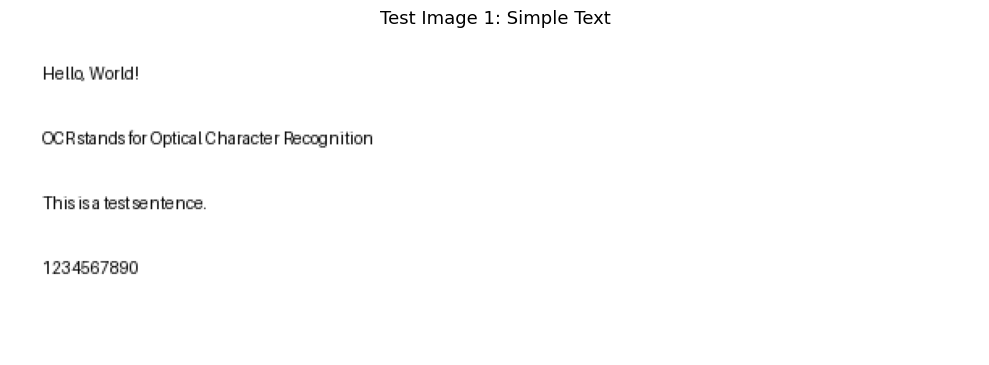

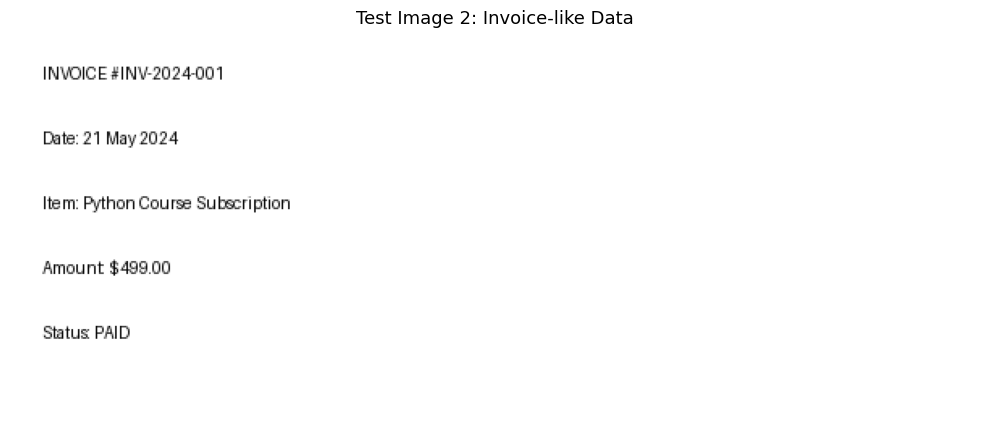

In [2]:
# ── Create a simple synthetic text image ─────────────────────────────────────

def create_text_image(lines, filename, img_size=(600, 200), bg=(255,255,255), fg=(0,0,0)):
    """
    Create a simple image with text lines using PIL.
    Returns the image as a numpy array.
    """
    from PIL import Image, ImageDraw, ImageFont
    
    img = Image.new('RGB', img_size, color=bg)
    draw = ImageDraw.Draw(img)
    
    y_start = 20
    for line in lines:
        draw.text((20, y_start), line, fill=fg)
        y_start += 40
    
    img.save(filename)
    return np.array(img)


# Test image 1: simple text
img1 = create_text_image(
    lines=["Hello, World!",
           "OCR stands for Optical Character Recognition",
           "This is a test sentence.",
           "1234567890"],
    filename="test_text.png"
)

# Test image 2: invoice-like data
img2 = create_text_image(
    lines=["INVOICE #INV-2024-001",
           "Date: 21 May 2024",
           "Item: Python Course Subscription",
           "Amount: $499.00",
           "Status: PAID"],
    filename="test_invoice.png",
    img_size=(600, 250)
)

show_image(img1, title="Test Image 1: Simple Text")
show_image(img2, title="Test Image 2: Invoice-like Data")

In [3]:
# ── Download a real-world image with text ─────────────────────────────────────
# We'll use a sign / road image that has visible text

real_image_url = "https://talkbusiness.net/wp-content/uploads/2021/11/AggieHerald1921-732x455.jpeg"

# NOTE: Replace with a URL to an image that clearly shows text, e.g.:
# - A street sign
# - A newspaper page
# - A product label
# For demonstration we use the PIL-created images above.

# Alternatively: place your own image file next to this notebook
# and set: real_image_path = "my_image.jpg"

print("ℹ️  Using PIL-generated test images for all examples.")
print("   To use your own image, set the 'image_path' variable in each section below.")

ℹ️  Using PIL-generated test images for all examples.
   To use your own image, set the 'image_path' variable in each section below.


---
## 4. EasyOCR

**EasyOCR** is the most beginner-friendly OCR library. It:
- Supports **80+ languages** out of the box
- Works well on natural scene images (not just clean documents)
- Returns text, bounding boxes, and confidence scores
- Based on CRAFT (text detection) + ResNet+LSTM (recognition)

### How it works internally:
```
Image
  ↓
CRAFT text detector → finds text regions
  ↓
CRNN (CNN + BiLSTM + CTC) → reads text in each region
  ↓
Output: [(bounding_box, text, confidence), ...]
```

In [4]:
# ── EasyOCR: Basic Usage ──────────────────────────────────────────────────────

import easyocr

# Step 1: Create a Reader object
# - ['en'] means English only; add more languages like ['en', 'fr', 'ar']
# - gpu=False forces CPU (set to True if you have a GPU)
# - First time: downloads model weights (~200 MB)
reader = easyocr.Reader(['en'], gpu=False)
print("✅ EasyOCR reader ready!")

Using CPU. Note: This module is much faster with a GPU.


✅ EasyOCR reader ready!


In [5]:
# ── EasyOCR: Run OCR on test image ────────────────────────────────────────────

# Read text from the test image
# readtext() returns a list of tuples:
#   (bounding_box, text_string, confidence)
results = reader.readtext('newspaper.jpeg')

print("OCR Results from test_text.png:\n")
for (bbox, text, confidence) in results:
    print(f"  Text: '{text}'")
    print(f"  Confidence: {confidence:.2%}")
    print(f"  Bounding Box: {bbox}")
    print()

c:\Users\zebsh\miniconda3\envs\dhruv_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OCR Results from test_text.png:

  Text: 'Hio Conig'
  Confidence: 19.83%
  Bounding Box: [[np.int32(31), np.int32(41)], [np.int32(111), np.int32(41)], [np.int32(111), np.int32(81)], [np.int32(31), np.int32(81)]]

  Text: 'AGGIE HERALD'
  Confidence: 98.95%
  Bounding Box: [[np.int32(121), np.int32(27)], [np.int32(611), np.int32(27)], [np.int32(611), np.int32(95)], [np.int32(121), np.int32(95)]]

  Text: 'Welcome]'
  Confidence: 53.30%
  Bounding Box: [[np.int32(620), np.int32(46)], [np.int32(700), np.int32(46)], [np.int32(700), np.int32(78)], [np.int32(620), np.int32(78)]]

  Text: '"WE ARE BOOSTERS OF THE WONDER STATE"'
  Confidence: 67.09%
  Bounding Box: [[np.int32(173), np.int32(92)], [np.int32(557), np.int32(92)], [np.int32(557), np.int32(113)], [np.int32(173), np.int32(113)]]

  Text: 'Jotesii'
  Confidence: 7.17%
  Bounding Box: [[np.int32(258), np.int32(124)], [np.int32(308), np.int32(124)], [np.int32(308), np.int32(132)], [np.int32(258), np.int32(132)]]

  Text: '4utm'
  Conf

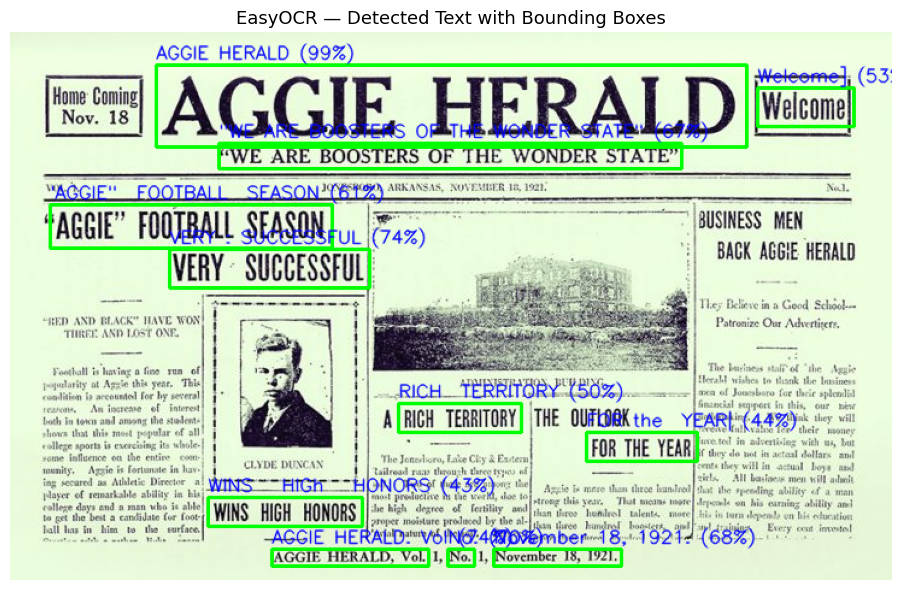

In [6]:
# ── EasyOCR: Visualise Bounding Boxes ────────────────────────────────────────

def draw_easyocr_results(image_path, ocr_results, min_confidence=0.3):
    """
    Draw bounding boxes and text from EasyOCR results on the image.
    
    EasyOCR bbox format: list of 4 corner points:
    [[top-left-x, top-left-y], [top-right], [bottom-right], [bottom-left]]
    """
    img = cv2.imread(image_path)
    
    for (bbox, text, confidence) in ocr_results:
        if confidence < min_confidence:
            continue
        
        # Convert corner points to integers
        pts = np.array(bbox, dtype=np.int32)
        
        # Draw the quadrilateral bounding box
        cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
        
        # Put text label above the box
        top_left = tuple(pts[0])  # first corner point
        cv2.putText(img, f"{text} ({confidence:.0%})",
                    (top_left[0], top_left[1] - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
    
    return img


# Visualise
annotated = draw_easyocr_results('newspaper.jpeg', results)
show_image(annotated, title="EasyOCR — Detected Text with Bounding Boxes")

c:\Users\zebsh\miniconda3\envs\dhruv_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted text from invoice image:



c:\Users\zebsh\miniconda3\envs\dhruv_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  → INVOICE #INV-2024-001
  → Date: 21 May 2024
  → Item: Python Course Subocription
  → cmount
  → $499.00
  → Status PAID


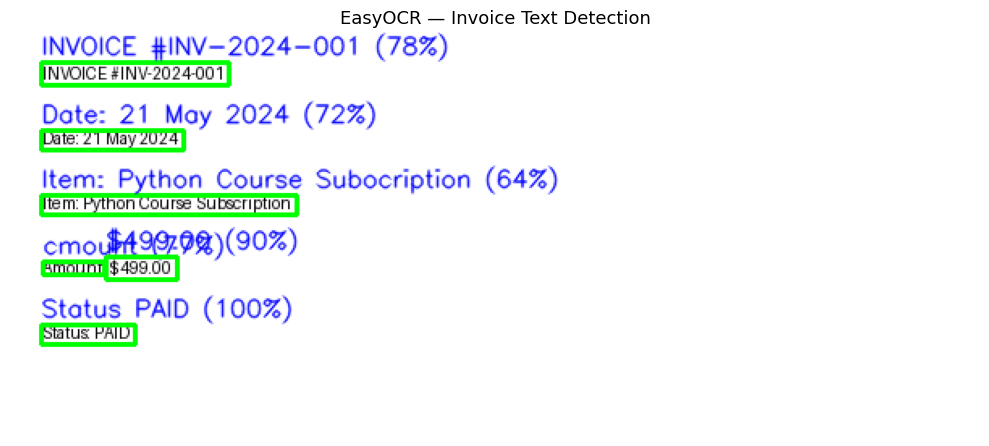

In [20]:
# ── EasyOCR: Test on Invoice Image ───────────────────────────────────────────

invoice_results = reader.readtext('test_invoice.png')

print("Extracted text from invoice image:\n")
# detail=0 mode just returns the text strings (no bbox/conf)
plain_results = reader.readtext('test_invoice.png', detail=0)
for line in plain_results:
    print(f"  → {line}")

# Visualise
annotated_inv = draw_easyocr_results('test_invoice.png', invoice_results)
show_image(annotated_inv, title="EasyOCR — Invoice Text Detection")

In [21]:
# ── EasyOCR: Key Parameters Explained ────────────────────────────────────────

# EasyOCR has many parameters to control accuracy vs speed
# Here's a demo of the key ones:

results_tuned = reader.readtext(
    'newspaper.jpeg',
    
    # paragraph=True: merge nearby text into paragraphs
    paragraph=False,
    
    # width_ths: max horizontal distance between words to merge
    width_ths=0.7,
    
    # contrast_ths: contrast enhancement threshold
    contrast_ths=0.1,
    
    # adjust_contrast: how much to enhance contrast
    adjust_contrast=0.5,
    
    # text_threshold: minimum confidence to consider as text (0–1)
    text_threshold=0.7,
    
    # low_text: sensitivity to low-contrast text
    low_text=0.4,
)

print("Tuned EasyOCR results:")
for (bbox, text, conf) in results_tuned:
    print(f"  '{text}' — conf: {conf:.2%}")

c:\Users\zebsh\miniconda3\envs\dhruv_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tuned EasyOCR results:
  'Hio Conig' — conf: 19.83%
  'AGGIE HERALD' — conf: 98.95%
  'Welcome]' — conf: 53.30%
  '"WE ARE BOOSTERS OF THE WONDER STATE"' — conf: 67.09%
  'Jotesii' — conf: 7.17%
  '4utm' — conf: 3.05%
  ''AGGIE"  FOOTBALL  SEASON' — conf: 60.70%
  '(BuSINesS   MEN' — conf: 26.21%
  'Back   aGche  hebald' — conf: 19.08%
  'VERY : SUCCESSFUL' — conf: 74.21%
  'He; Dlrie in # Goed sckoo=' — conf: 3.66%
  '"KFD AN Mica" imic Woy' — conf: 0.84%
  'Pattonirc Our Ahr rtizces,' — conf: 12.92%
  'TIUFL AS U[OTE' — conf: 1.27%
  'Tlll' — conf: 15.46%
  'hntini' — conf: 20.37%
  'TkFu tc' — conf: 3.32%
  'Ueluratali' — conf: 0.69%
  'Aae 0 Lhit )eafs' — conf: 4.28%
  'ADMGIISTI !TIo] BILDLG' — conf: 2.41%
  'Wuaehnteeueaneneninaly' — conf: 0.00%
  'Tanii' — conf: 9.89%
  'Accuuac] for' — conf: 6.19%
  'Iirri' — conf: 10.91%
  'Jul aius Ieer ehti: ' — conf: 0.05%
  'calla' — conf: 1.68%
  'eflA' — conf: 2.28%
  'Enlcrey' — conf: 28.10%
  'ulotimhi' — conf: 1.92%
  'Lu lenanan| ana

---
## 5. PaddleOCR

**PaddleOCR** is Baidu's production-grade OCR framework. It's more accurate than EasyOCR on complex documents and offers a modular pipeline.

### Pipeline stages:
```
Image
  ↓
DBNet  → text detection (finds text region polygons)
  ↓  
SVTR/PP-OCRv4 → recognition (reads text in each box)
  ↓
Optional: text direction correction, table parsing, layout analysis
```

### Key advantages over EasyOCR:
- **Better accuracy** on dense text and complex layouts
- **Table extraction** support
- **Layout analysis** (headings, paragraphs, tables)
- Supports **angle correction** (rotated text)
- Lightweight models available for edge deployment

In [22]:
# ── PaddleOCR: Basic Usage ────────────────────────────────────────────────────

from paddleocr import PaddleOCR

# engine="transformers" uses HuggingFace Transformers as the backend instead of
# PaddlePaddle's static inference engine, which has a known Windows/oneDNN bug
# (ConvertPirAttribute2RuntimeAttribute not supported).
ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    engine="transformers",
    lang='en',
)

print("✅ PaddleOCR initialised!")

Creating model: ('PP-OCRv5_server_det', None, 'transformers')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\zebsh\.paddlex\official_models\PP-OCRv5_server_det_safetensors`.


Loading weights: 100%|██████████| 539/539 [00:00<00:00, 5057.86it/s]
Creating model: ('en_PP-OCRv5_mobile_rec', None, 'transformers')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\zebsh\.paddlex\official_models\en_PP-OCRv5_mobile_rec_safetensors`.
Loading weights: 100%|██████████| 884/884 [00:00<00:00, 5560.62it/s]


✅ PaddleOCR initialised!


In [23]:
# ── PaddleOCR: Run OCR ────────────────────────────────────────────────────────

result = ocr.predict('newspaper.jpeg')

# result is a list of result objects, one per image.
# Each result is a dict-like object with keys:
#   'rec_texts'  — list of recognised strings
#   'rec_scores' — list of confidence scores
#   'rec_boxes'  — list of bounding boxes [x_min, y_min, x_max, y_max]
res = result[0]

print("PaddleOCR Results:\n")
for text, score, box in zip(res['rec_texts'], res['rec_scores'], res['rec_boxes']):
    print(f"  Text: '{text}'")
    print(f"  Confidence: {score:.2%}")
    print()

PaddleOCR Results:

  Text: 'AGGIE HERALD'
  Confidence: 98.54%

  Text: 'Home Coming'
  Confidence: 98.21%

  Text: 'Welcome'
  Confidence: 99.79%

  Text: 'Nov. 18'
  Confidence: 98.92%

  Text: '"WE ARE BOOSTERS OF THE WONDER STATE"'
  Confidence: 96.27%

  Text: 'vot.'1.'
  Confidence: 82.65%

  Text: 'JONESBORO, ARKANSAS, NOVEMBER 18, 192L.'
  Confidence: 96.12%

  Text: 'No.l.'
  Confidence: 92.95%

  Text: '"AGGIE" FOOTBALL SEASON'
  Confidence: 96.17%

  Text: 'BUSINESS MEN'
  Confidence: 99.98%

  Text: 'VERY SUCCESSFUL'
  Confidence: 95.92%

  Text: 'BACK AGGIE HERALD'
  Confidence: 99.92%

  Text: 'They Believe in a Good School--'
  Confidence: 96.55%

  Text: '"RED AND BLACK" HAVE WON'
  Confidence: 97.67%

  Text: 'Patronize Our Advertigers.'
  Confidence: 95.82%

  Text: 'THIREE AND LOST ONE.'
  Confidence: 96.16%

  Text: 'Foothall is having a fine run of'
  Confidence: 96.69%

  Text: 'The buines stali' of 'the Aggie'
  Confidence: 84.61%

  Text: 'popularity at Aggie t

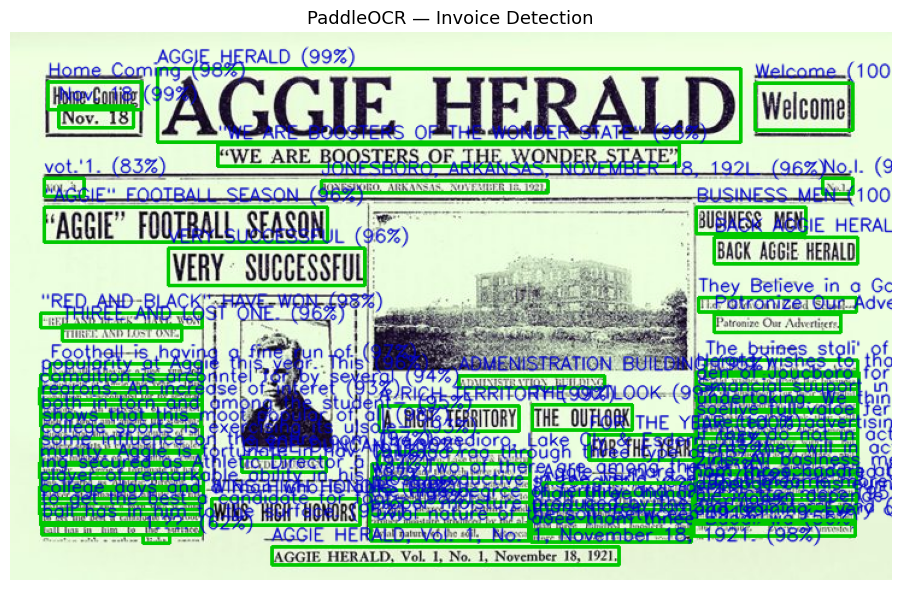

In [24]:
# ── PaddleOCR: Visualise Results ─────────────────────────────────────────────

img_draw = cv2.imread('newspaper.jpeg')

for text, score, box in zip(res['rec_texts'], res['rec_scores'], res['rec_boxes']):
    # rec_boxes format: [x_min, y_min, x_max, y_max]
    x1, y1, x2, y2 = [int(v) for v in box]
    cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 200, 0), 2)
    cv2.putText(img_draw, f"{text} ({score:.0%})", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 0, 0), 1, cv2.LINE_AA)

show_image(img_draw, title="PaddleOCR — Invoice Detection")

In [14]:
# ── PaddleOCR: Detection-Only Mode ───────────────────────────────────────────
from paddleocr import TextDetection

det_model = TextDetection(engine="transformers")
det_result = det_model.predict('newspaper.jpeg')

print("Text detection only (bounding boxes, no text content):\n")
for i, box in enumerate(det_result[0]['dt_polys']):
    print(f"  Region {i+1}: {box.tolist()}")

# ── PaddleOCR: Recognition-Only Mode ─────────────────────────────────────────
# For pre-cropped word images, use TextRecognition directly:
# from paddleocr import TextRecognition
# rec_model = TextRecognition(engine="transformers")
# rec_result = rec_model.predict('cropped_word.png')
print("\n(Recognition-only: use paddleocr.TextRecognition on cropped images)")

Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\zebsh\.paddlex\official_models\PP-OCRv5_server_det_safetensors`.
Loading weights: 100%|██████████| 539/539 [00:00<00:00, 5889.60it/s]


Text detection only (bounding boxes, no text content):

  Region 1: [[217, 427], [505, 427], [505, 442], [217, 442]]
  Region 2: [[110, 417], [132, 417], [132, 424], [110, 424]]
  Region 3: [[54, 417], [107, 417], [107, 425], [54, 425]]
  Region 4: [[432, 413], [565, 413], [565, 423], [432, 423]]
  Region 5: [[299, 409], [430, 410], [430, 422], [299, 421]]
  Region 6: [[26, 407], [158, 407], [158, 417], [26, 417]]
  Region 7: [[567, 405], [701, 406], [701, 418], [567, 417]]
  Region 8: [[432, 403], [565, 404], [565, 416], [432, 414]]
  Region 9: [[298, 400], [430, 400], [430, 410], [298, 410]]
  Region 10: [[25, 397], [158, 396], [159, 408], [26, 409]]
  Region 11: [[568, 394], [701, 396], [701, 408], [568, 406]]
  Region 12: [[433, 392], [566, 394], [566, 406], [433, 404]]
  Region 13: [[298, 390], [431, 390], [431, 400], [298, 400]]
  Region 14: [[167, 387], [290, 387], [290, 409], [167, 409]]
  Region 15: [[24, 387], [159, 387], [159, 400], [24, 400]]
  Region 16: [[569, 384], [702,

---
## 6. TrOCR — Transformer-based OCR

**TrOCR** (Microsoft, HuggingFace) treats OCR as a **sequence-to-sequence** problem using a Vision Encoder + Language Decoder.

### Architecture:
```
Cropped text image
  ↓
Vision Encoder (ViT)  →  image patch embeddings
  ↓
Text Decoder (Transformer)  →  generates text token by token
  ↓
Output: recognised text string
```

### Key difference from EasyOCR / PaddleOCR:
- TrOCR is a **recognition-only** model — it assumes you already have a cropped text region
- You need a separate **text detector** to find the regions first
- It's best for **high-quality, printed text** (documents, forms)
- TrOCR-large achieves state-of-the-art on printed document benchmarks

### Model variants:
| Model | Size | Best for |
|---|---|---|
| `trocr-small-printed` | Small | Quick testing, printed text |
| `trocr-base-printed` | Base | Balance of speed + accuracy |
| `trocr-large-printed` | Large | Highest accuracy, slower |
| `trocr-base-handwritten` | Base | Handwriting recognition |

In [15]:
# ── TrOCR: Load Model ────────────────────────────────────────────────────────
# First run downloads model weights (~400 MB for base)

from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch

# Load the processor (tokenizer + image processor) and model
print("Loading TrOCR model (may take a moment on first run)...")

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model_trocr = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed')

# Move to GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_trocr = model_trocr.to(device)

print(f"✅ TrOCR loaded! Running on: {device}")

Loading TrOCR model (may take a moment on first run)...


c:\Users\zebsh\miniconda3\envs\dhruv_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zebsh\.cache\huggingface\hub\models--microsoft--trocr-base-printed. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 478/478 [00:00<00:00, 6591.65it/s]
[transformers] VisionEncoderDe

✅ TrOCR loaded! Running on: cpu


In [16]:
# ── TrOCR: Recognise Text from Cropped Images ─────────────────────────────────

def trocr_read(image_pil):
    """
    Use TrOCR to read text from a single cropped image.
    
    Parameters:
        image_pil: PIL Image (cropped text region, RGB)
    
    Returns:
        recognised text string
    """
    # Step 1: Preprocess the image for the model
    pixel_values = processor(images=image_pil, return_tensors='pt').pixel_values
    pixel_values = pixel_values.to(device)
    
    # Step 2: Generate text (auto-regressively)
    with torch.no_grad():
        generated_ids = model_trocr.generate(pixel_values)
    
    # Step 3: Decode token IDs back to text string
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    
    return generated_text


# Test on our synthetic invoice image (full image as input)
img_pil = Image.open('test_invoice.png').convert('RGB')
trocr_output = trocr_read(img_pil)

print("TrOCR output (full image):")
print(f"  → '{trocr_output}'")
print()
print("Note: TrOCR works best on individual cropped word/line images.")
print("For multi-line documents, first use a detector, then feed each crop to TrOCR.")

c:\Users\zebsh\miniconda3\envs\dhruv_env\Lib\site-packages\transformers\generation\utils.py:1610: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


TrOCR output (full image):
  → '***'

Note: TrOCR works best on individual cropped word/line images.
For multi-line documents, first use a detector, then feed each crop to TrOCR.


In [17]:
# ── TrOCR: Combined with EasyOCR Detection ───────────────────────────────────
# Best of both worlds: EasyOCR for detection, TrOCR for recognition

def ocr_pipeline_hybrid(image_path, reader, trocr_proc, trocr_model, device='cpu'):
    """
    Hybrid OCR pipeline:
    1. EasyOCR detects text bounding boxes
    2. Each box is cropped from the image
    3. TrOCR reads each cropped region
    
    Returns list of (bbox, text) tuples.
    """
    img_cv = cv2.imread(image_path)
    img_pil = Image.open(image_path).convert('RGB')
    
    # Step 1: Detection with EasyOCR (detection only)
    # paragraph=False to get individual word boxes
    detections = reader.detect(image_path)
    
    results = []
    
    if detections and detections[0]:
        for bbox in detections[0][0]:  # horizontal boxes
            # bbox format: [x_min, x_max, y_min, y_max]
            x_min, x_max, y_min, y_max = [int(v) for v in bbox]
            
            # Add small padding
            pad = 5
            x_min = max(0, x_min - pad)
            y_min = max(0, y_min - pad)
            x_max = min(img_pil.width, x_max + pad)
            y_max = min(img_pil.height, y_max + pad)
            
            # Step 2: Crop the region
            crop = img_pil.crop((x_min, y_min, x_max, y_max))
            
            if crop.width < 5 or crop.height < 5:
                continue  # skip tiny boxes
            
            # Step 3: Recognise with TrOCR
            pixel_values = trocr_proc(images=crop, return_tensors='pt').pixel_values.to(device)
            with torch.no_grad():
                ids = trocr_model.generate(pixel_values)
            text = trocr_proc.batch_decode(ids, skip_special_tokens=True)[0]
            
            if text.strip():
                results.append(((x_min, y_min, x_max, y_max), text))
    
    return results


# Run the hybrid pipeline
print("Running hybrid EasyOCR (detect) + TrOCR (recognise) pipeline...")
hybrid_results = ocr_pipeline_hybrid(
    'test_invoice.png', reader, processor, model_trocr, device
)

print("\nHybrid Pipeline Results:")
for bbox, text in hybrid_results:
    print(f"  [{bbox[0]},{bbox[1]} → {bbox[2]},{bbox[3]}]  →  '{text}'")

Running hybrid EasyOCR (detect) + TrOCR (recognise) pipeline...


c:\Users\zebsh\miniconda3\envs\dhruv_env\Lib\site-packages\transformers\generation\utils.py:1610: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(



Hybrid Pipeline Results:
  [14,14 → 140,38]  →  'INVOICE #INV-2024-001'
  [14,56 → 112,78]  →  'DATE: 21 MAY 2024'
  [14,96 → 182,118]  →  'ITEM: PYTHON COURSE SUBCRIPTION'
  [15,137 → 63,155]  →  'AMOUNT:'
  [54,134 → 108,158]  →  'T $499.00'
  [14,176 → 82,198]  →  'STATUS PAID'


---
## 7. Choosing the Right Tool

| Scenario | Recommended Tool | Why |
|---|---|---|
| Quick prototype, single language | **EasyOCR** | Simplest API, great defaults |
| Multi-language (80+ langs) | **EasyOCR** | Best language coverage |
| Production, high accuracy | **PaddleOCR** | Most accurate, table support |
| Dense documents / forms | **PaddleOCR** | Layout analysis built-in |
| Scanned documents, high quality | **TrOCR** | Transformer quality on clean text |
| Handwriting recognition | **TrOCR-handwritten** | Specific model variant |
| Rotated / skewed text | **PaddleOCR** | Angle correction built-in |
| Mobile / edge device | **PaddleOCR-lite** | Smallest model sizes |
| Real-time video | **EasyOCR** | Fastest for real-time use |

In [18]:
# ── Speed & Output Comparison ─────────────────────────────────────────────────

import time

test_file = 'test_text.png'

# EasyOCR timing
start = time.time()
easy_out = reader.readtext(test_file, detail=0)
easy_time = time.time() - start

# PaddleOCR timing
start = time.time()
paddle_result = ocr.predict(test_file)
paddle_texts = paddle_result[0]['rec_texts']
paddle_time = time.time() - start

# TrOCR timing
start = time.time()
trocr_out = trocr_read(Image.open(test_file).convert('RGB'))
trocr_time = time.time() - start

print("┌─────────────────┬──────────────┬──────────────────────────────────────┐")
print("│ Library         │ Time (s)     │ Output                               │")
print("├─────────────────┼──────────────┼──────────────────────────────────────┤")
print(f"│ EasyOCR         │ {easy_time:8.2f}s   │ {str(easy_out)[:40]}... │")
print(f"│ PaddleOCR       │ {paddle_time:8.2f}s   │ {str(paddle_texts)[:40]}... │")
print(f"│ TrOCR           │ {trocr_time:8.2f}s   │ {str(trocr_out)[:40]}...      │")
print("└─────────────────┴──────────────┴──────────────────────────────────────┘")

c:\Users\zebsh\miniconda3\envs\dhruv_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\zebsh\miniconda3\envs\dhruv_env\Lib\site-packages\transformers\generation\utils.py:1610: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


┌─────────────────┬──────────────┬──────────────────────────────────────┐
│ Library         │ Time (s)     │ Output                               │
├─────────────────┼──────────────┼──────────────────────────────────────┤
│ EasyOCR         │     0.61s   │ ['Hella Worldl', 'OCRstands for Optical ... │
│ PaddleOCR       │     5.09s   │ ['He llo wvorld!', 'OC Rstands for Optic... │
│ TrOCR           │     0.69s   │ ********...      │
└─────────────────┴──────────────┴──────────────────────────────────────┘


---
## 8. Real-World Pipeline — Structured Data Extraction

A common real-world task: extract **specific fields** from a document (invoice, receipt, form).

### Approach:
1. Run OCR to get all text
2. Use regex or keyword matching to find fields
3. Return a structured dictionary

In [ ]:
# ── Structured Data Extraction from Invoice ───────────────────────────────────

import re

def extract_invoice_data(image_path, reader):
    """
    Extract key fields from an invoice image using OCR + regex.
    
    Returns a dictionary with extracted fields.
    """
    # Step 1: Get all text from the image
    all_text_lines = reader.readtext(image_path, detail=0)
    full_text = ' '.join(all_text_lines)  # merge into one string
    
    # Step 2: Use regex to find specific patterns
    extracted = {}
    
    # Find invoice number (e.g., INV-2024-001)
    inv_match = re.search(r'INV[-\s]?[\w-]+', full_text, re.IGNORECASE)
    extracted['invoice_number'] = inv_match.group() if inv_match else None
    
    # Find date
    date_match = re.search(r'\d{1,2}\s+\w+\s+\d{4}', full_text)
    if not date_match:
        date_match = re.search(r'\d{4}-\d{2}-\d{2}', full_text)
    extracted['date'] = date_match.group() if date_match else None
    
    # Find amount (e.g., $499.00)
    amount_match = re.search(r'\$[\d,]+\.\d{2}', full_text)
    extracted['amount'] = amount_match.group() if amount_match else None
    
    # Find status
    status_match = re.search(r'\b(PAID|UNPAID|PENDING|OVERDUE)\b', full_text, re.IGNORECASE)
    extracted['status'] = status_match.group().upper() if status_match else None
    
    # Raw OCR output for reference
    extracted['raw_lines'] = all_text_lines
    
    return extracted


# Run extraction
invoice_data = extract_invoice_data('test_invoice.png', reader)

print("Extracted Invoice Data:")
print(f"  Invoice #:  {invoice_data['invoice_number']}")
print(f"  Date:       {invoice_data['date']}")
print(f"  Amount:     {invoice_data['amount']}")
print(f"  Status:     {invoice_data['status']}")
print(f"\nRaw OCR lines: {invoice_data['raw_lines']}")

---
## 9. Image Pre-processing for Better OCR

OCR accuracy depends heavily on **image quality**. These pre-processing steps can significantly improve results on noisy or low-contrast images.

In [ ]:
# ── OCR Pre-processing Techniques ─────────────────────────────────────────────

def preprocess_for_ocr(image_path):
    """
    Apply common pre-processing steps to improve OCR accuracy.
    Returns a dict of processed images for comparison.
    """
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    processed = {'original': img}
    
    # 1. Grayscale — remove colour noise
    processed['grayscale'] = gray
    
    # 2. Thresholding — convert to pure black & white
    # OTSU automatically finds the best threshold
    _, thresh_otsu = cv2.threshold(gray, 0, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    processed['threshold_otsu'] = thresh_otsu
    
    # 3. Adaptive thresholding — better for uneven lighting
    adaptive = cv2.adaptiveThreshold(gray, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 11, 2)
    processed['adaptive_threshold'] = adaptive
    
    # 4. Denoise — remove salt & pepper noise
    denoised = cv2.fastNlMeansDenoising(gray, h=10)
    processed['denoised'] = denoised
    
    # 5. Dilation — thicken thin text (helps with small fonts)
    kernel = np.ones((2, 2), np.uint8)
    dilated = cv2.dilate(thresh_otsu, kernel, iterations=1)
    processed['dilated'] = dilated
    
    # 6. Upscaling — enlarge small images (OCR works better on larger text)
    scale = 2.0
    h, w = gray.shape
    upscaled = cv2.resize(gray, (int(w * scale), int(h * scale)),
                          interpolation=cv2.INTER_CUBIC)
    processed['upscaled_2x'] = upscaled
    
    return processed


# Apply pre-processing
processed_versions = preprocess_for_ocr('test_invoice.png')

# Display all versions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, img) in enumerate(processed_versions.items()):
    if i < 6:
        if len(img.shape) == 3:
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            axes[i].imshow(img, cmap='gray')
        axes[i].set_title(name.replace('_', ' ').title(), fontsize=10)
        axes[i].axis('off')

plt.suptitle('Pre-processing Options for OCR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Compare OCR accuracy before/after pre-processing ──────────────────────────

# Save a pre-processed version and run EasyOCR on it
thresh_img = processed_versions['threshold_otsu']
cv2.imwrite('preprocessed.png', thresh_img)

# OCR on original
orig_results = reader.readtext('test_invoice.png', detail=0)

# OCR on pre-processed
proc_results = reader.readtext('preprocessed.png', detail=0)

print("Original image OCR:")
for t in orig_results:
    print(f"  → {t}")

print("\nPre-processed (thresholded) image OCR:")
for t in proc_results:
    print(f"  → {t}")

---
## 10. Exercises 📝

1. **Multi-language OCR** — Find an image with text in two different languages. Run EasyOCR with both language codes and compare results.

2. **Receipt parser** — Take a photo of a receipt (or find one online). Use any OCR library to extract: total amount, date, and store name.

3. **Rotation test** — Rotate `test_text.png` by 15 degrees using OpenCV. Run OCR on the rotated version and compare accuracy with/without PaddleOCR's angle correction (`use_angle_cls=True`).

4. **Handwriting** — Download a sample handwritten text image. Try TrOCR with `microsoft/trocr-base-handwritten` and compare to EasyOCR.

5. **Live screen OCR** — Take a screenshot of your screen (use `PIL.ImageGrab.grab()`), run EasyOCR on it, and print all detected text.

---
## Summary

| Concept | Key Takeaway |
|---|---|
| OCR pipeline | Text Detection → Text Recognition |
| EasyOCR | Simplest API, 80+ languages, CRAFT + CRNN |
| PaddleOCR | Most accurate, tables, angle correction |
| TrOCR | Transformer-based, best for clean documents & handwriting |
| Pre-processing | Thresholding, denoising, upscaling improve accuracy |
| Structured extraction | OCR output + regex = structured data |

### Next in Session 13
- **Notebook 13B**: Face Recognition Pipeline — Detect → Align → Embed → Match

---
*Session 13A | OCR & Text Detection | Computer Vision & AI Course*